In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries loaded ✅")

All libraries loaded ✅


In [2]:
df = pd.read_csv('../data/creditcard.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Transactions: {len(df):,}")
print(f"Features: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum().sum()} total missing")

Dataset Shape: (284807, 31)
Total Transactions: 284,807
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
0 total missing


Class Distribution:
Normal transactions: 284,315 (99.83%)
Fraud transactions:  492 (0.17%)


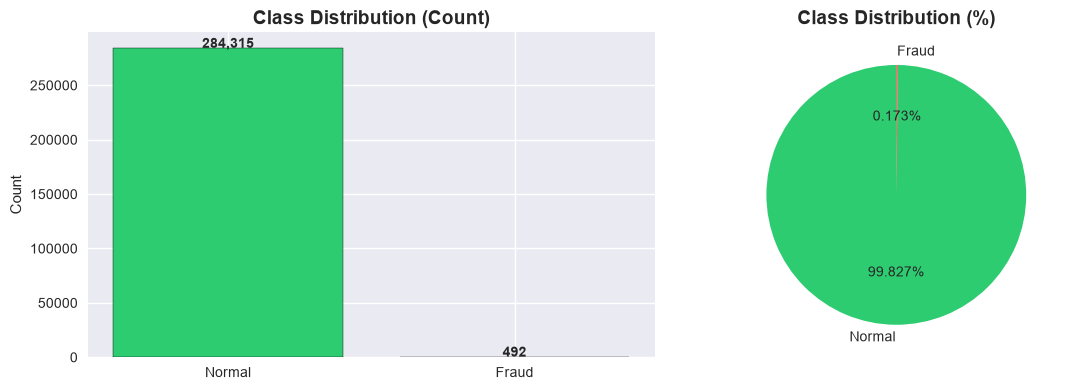


⚠️ Highly imbalanced dataset — fraud is only 0.17% of transactions


In [3]:
fraud_count = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"Normal transactions: {fraud_count[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Fraud transactions:  {fraud_count[1]:,} ({fraud_pct[1]:.2f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Normal', 'Fraud'], fraud_count.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_count.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Percentage plot
axes[1].pie(fraud_pct.values, labels=['Normal', 'Fraud'], 
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.3f%%', startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n⚠️ Highly imbalanced dataset — fraud is only 0.17% of transactions")

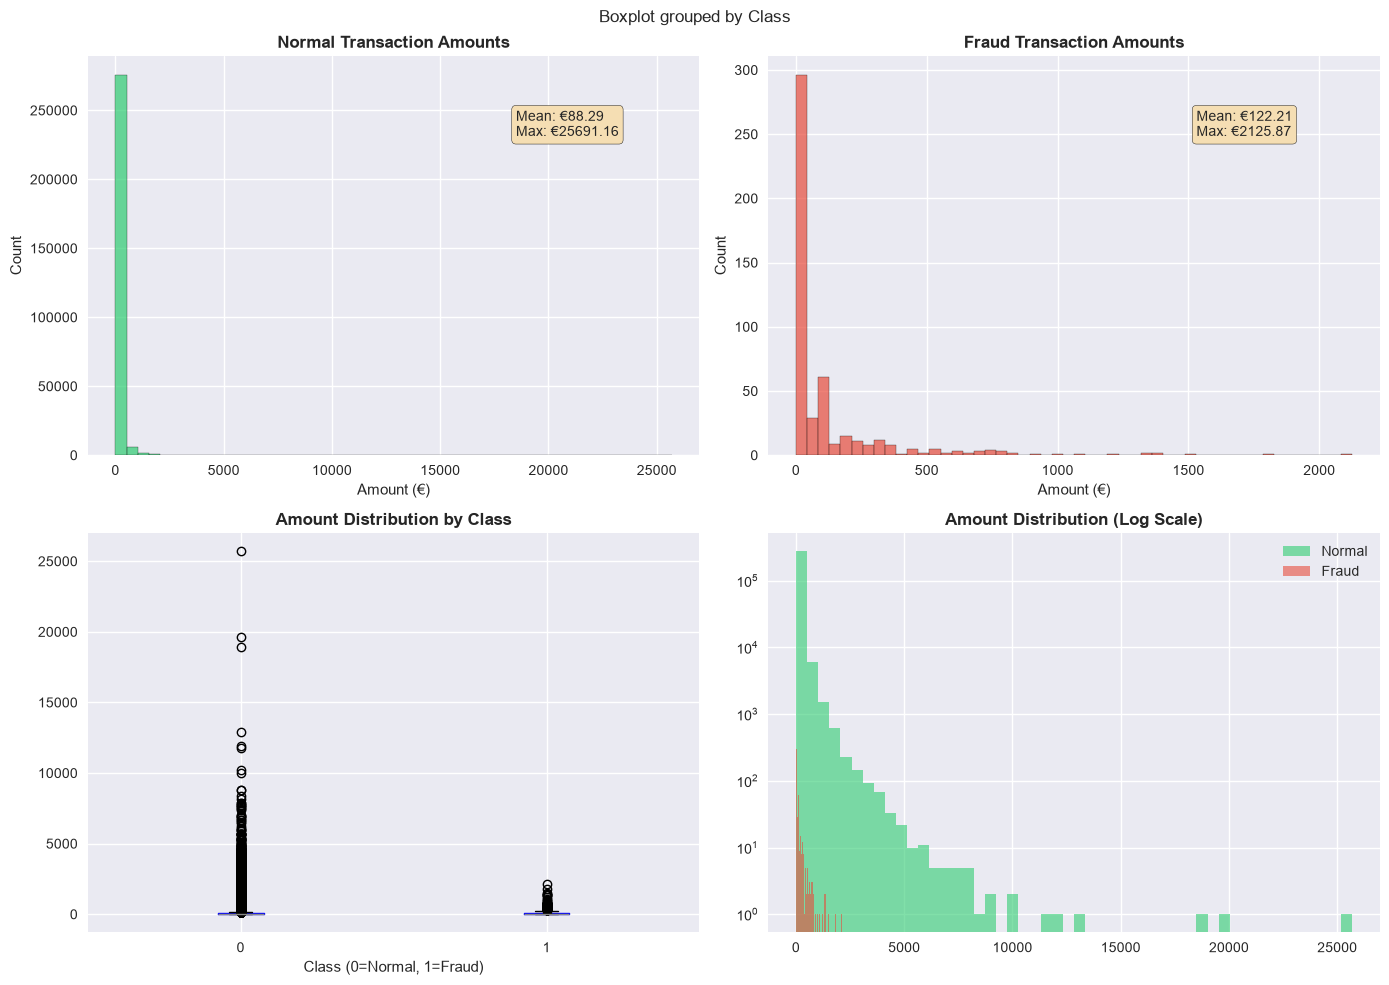

Normal - Mean: €88.29, Max: €25691.16
Fraud  - Mean: €122.21, Max: €2125.87


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution by class
for idx, (cls, label, color) in enumerate([(0, 'Normal', '#2ecc71'), (1, 'Fraud', '#e74c3c')]):
    data = df[df['Class'] == cls]['Amount']
    axes[0][idx].hist(data, bins=50, color=color, edgecolor='black', alpha=0.7)
    axes[0][idx].set_title(f'{label} Transaction Amounts', fontsize=12, fontweight='bold')
    axes[0][idx].set_xlabel('Amount (€)')
    axes[0][idx].set_ylabel('Count')
    axes[0][idx].text(0.7, 0.8, f'Mean: €{data.mean():.2f}\nMax: €{data.max():.2f}', 
                      transform=axes[0][idx].transAxes, fontsize=10,
                      bbox=dict(boxstyle='round', facecolor='wheat'))

# Boxplot comparison
df.boxplot(column='Amount', by='Class', ax=axes[1][0], 
           boxprops=dict(color='blue'))
axes[1][0].set_title('Amount Distribution by Class', fontsize=12, fontweight='bold')
axes[1][0].set_xlabel('Class (0=Normal, 1=Fraud)')

# Log scale amount
axes[1][1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, 
                label='Normal', color='#2ecc71')
axes[1][1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6, 
                label='Fraud', color='#e74c3c')
axes[1][1].set_yscale('log')
axes[1][1].set_title('Amount Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1][1].legend()

plt.tight_layout()
plt.savefig('../models/amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Normal - Mean: €{df[df['Class']==0]['Amount'].mean():.2f}, "
      f"Max: €{df[df['Class']==0]['Amount'].max():.2f}")
print(f"Fraud  - Mean: €{df[df['Class']==1]['Amount'].mean():.2f}, "
      f"Max: €{df[df['Class']==1]['Amount'].max():.2f}")

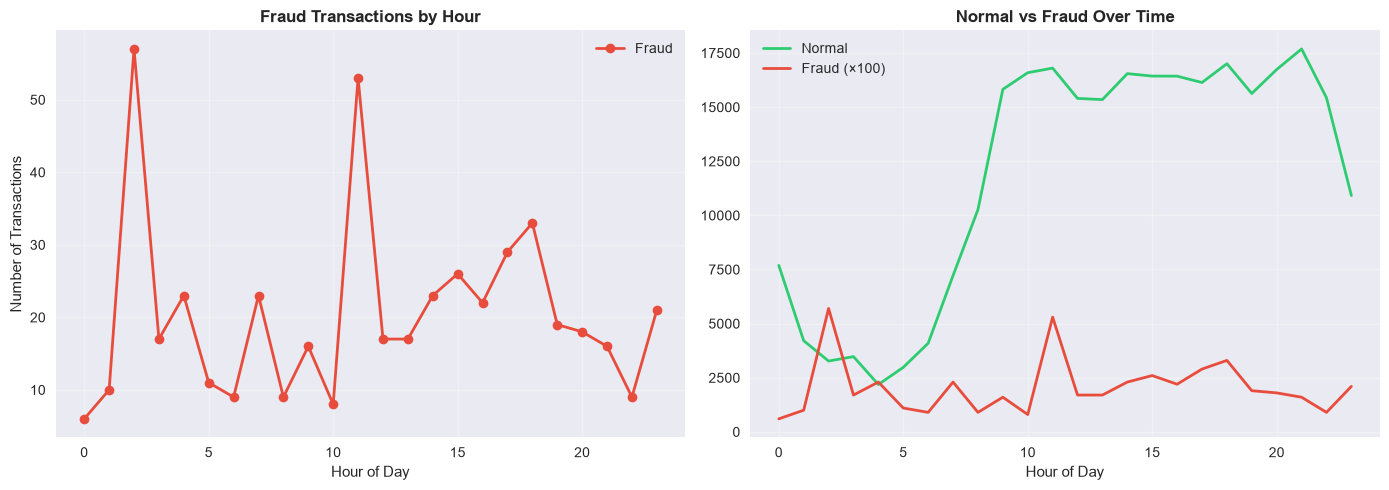

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud by hour
df['Hour'] = (df['Time'] // 3600) % 24
hourly_fraud = df[df['Class']==1].groupby('Hour').size()
hourly_normal = df[df['Class']==0].groupby('Hour').size()

axes[0].plot(hourly_fraud.index, hourly_fraud.values, 
             color='#e74c3c', marker='o', linewidth=2, label='Fraud')
axes[0].set_title('Fraud Transactions by Hour', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Normal vs Fraud over time
axes[1].plot(hourly_normal.index, hourly_normal.values, 
             color='#2ecc71', linewidth=2, label='Normal')
axes[1].plot(hourly_fraud.index, hourly_fraud.values * 100, 
             color='#e74c3c', linewidth=2, label='Fraud (×100)')
axes[1].set_title('Normal vs Fraud Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

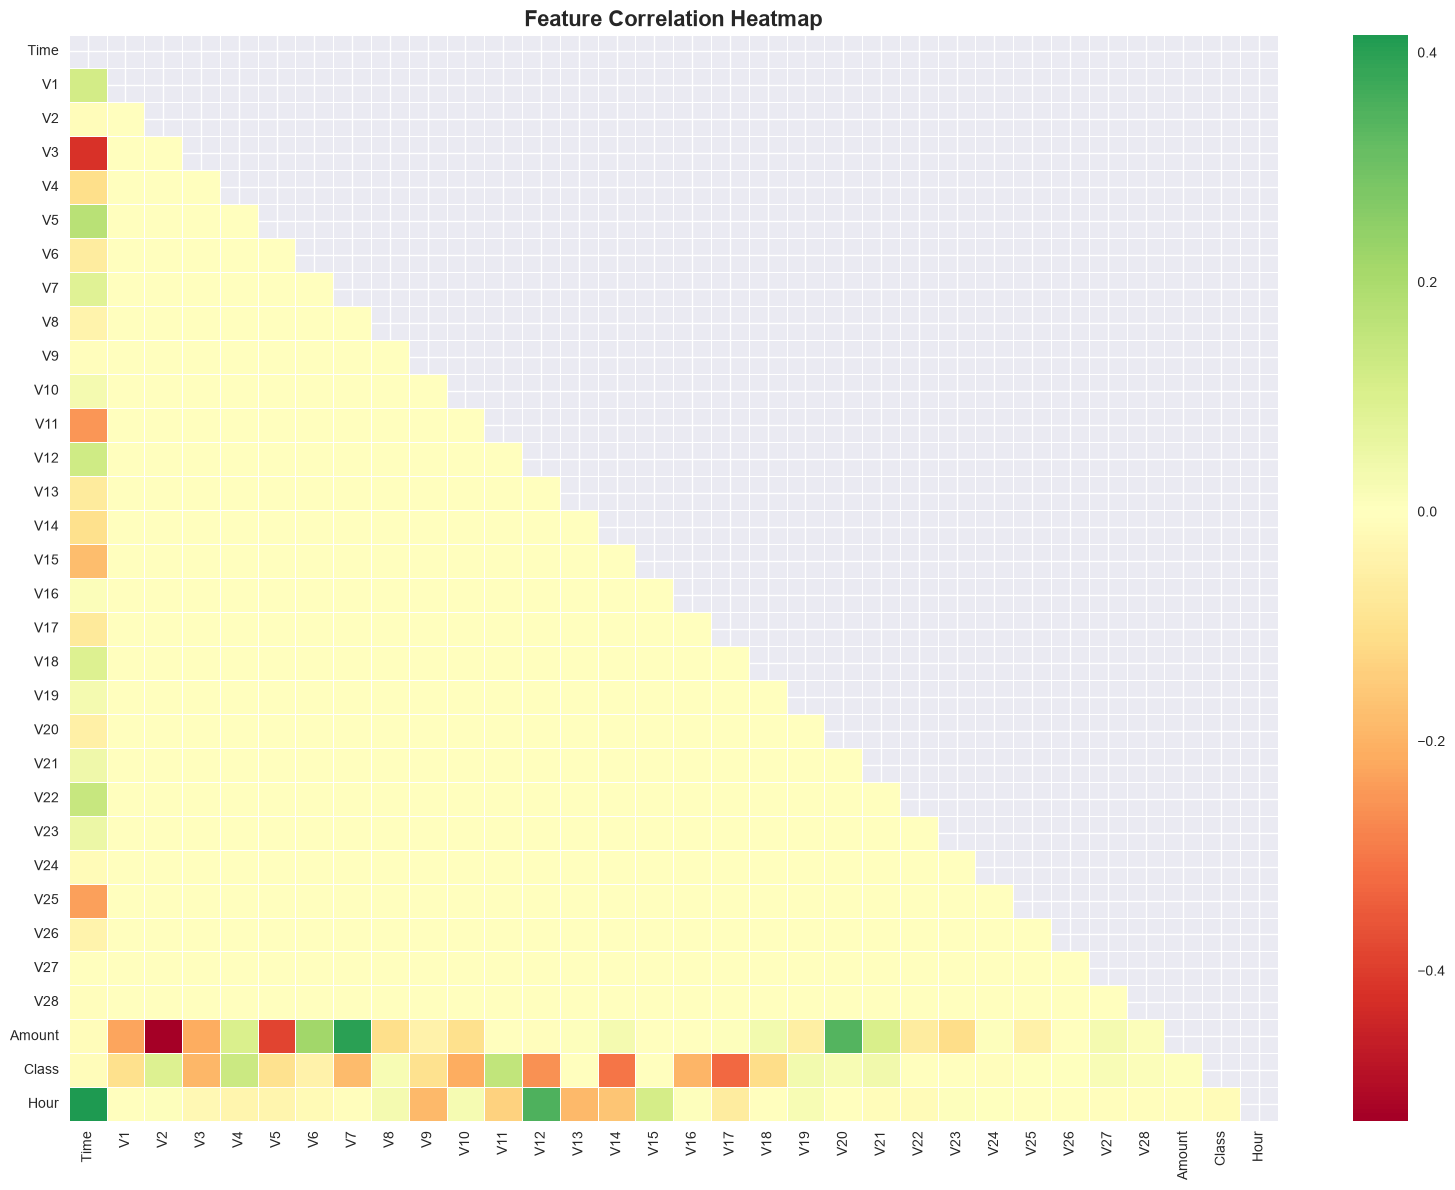

Top 10 features correlated with Fraud:
Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
V18      0.111485
Name: Class, dtype: float64


In [6]:
plt.figure(figsize=(16, 12))

corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, 
            cmap='RdYlGn', center=0,
            linewidths=0.5, fmt='.2f')

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with fraud
fraud_corr = corr_matrix['Class'].abs().sort_values(ascending=False)
print("Top 10 features correlated with Fraud:")
print(fraud_corr.head(11))

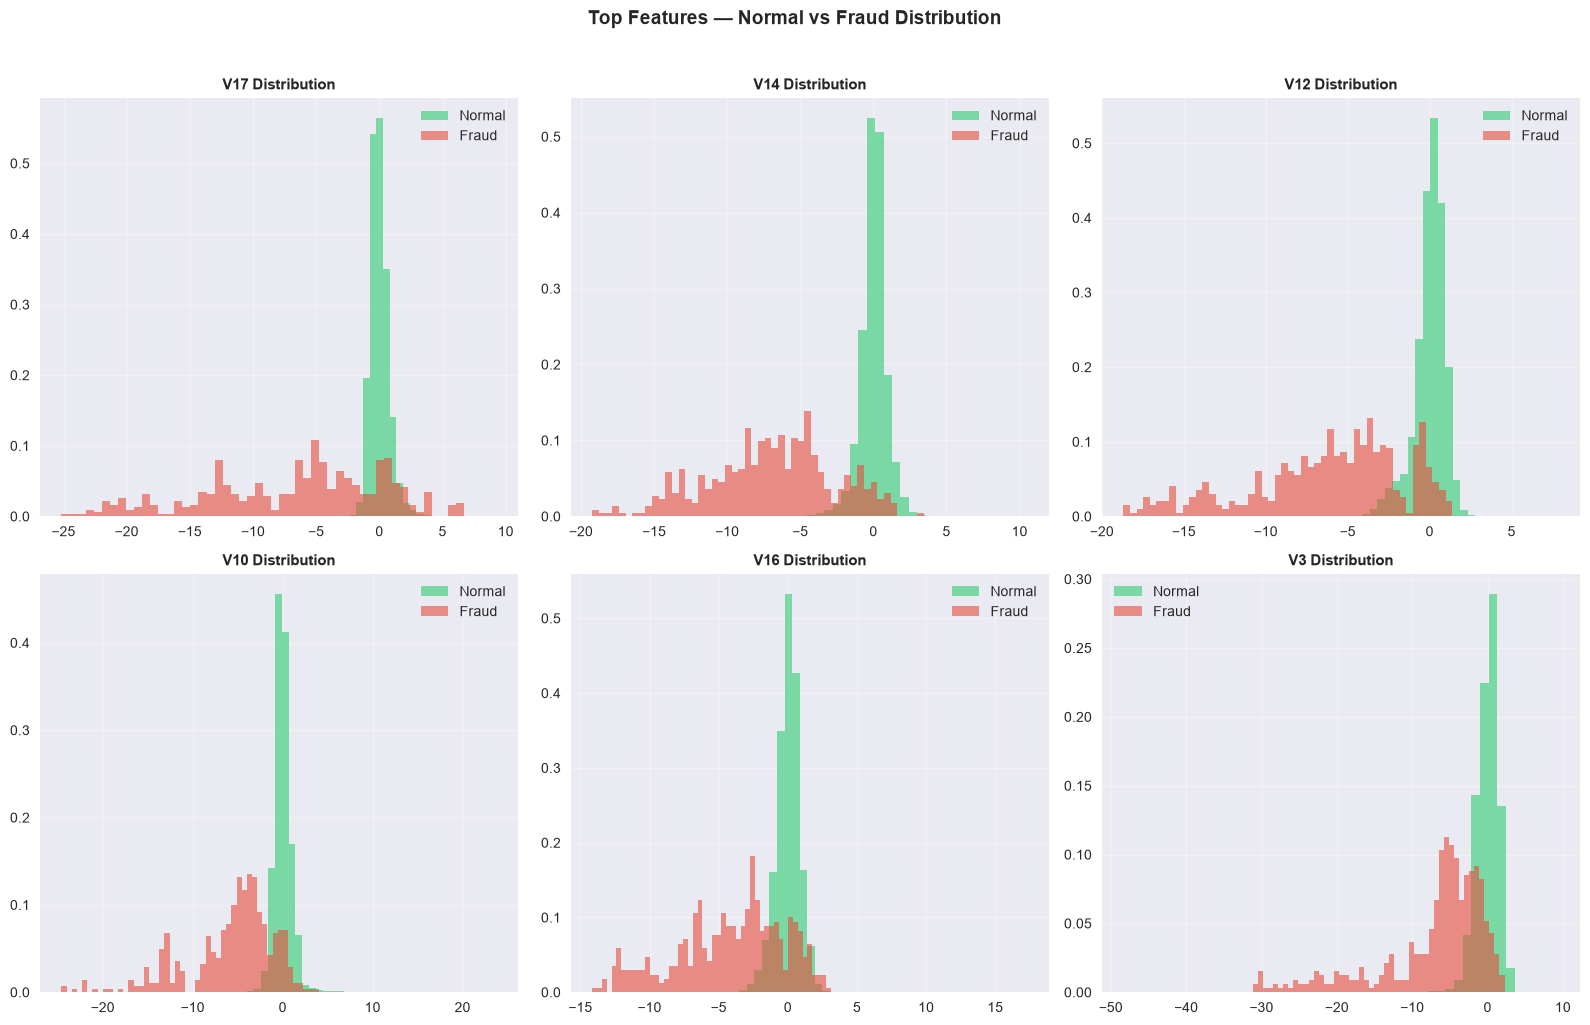

In [7]:
# Top 6 features most correlated with fraud
top_features = fraud_corr.index[1:7].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    normal_data = df[df['Class']==0][feature]
    fraud_data = df[df['Class']==1][feature]
    
    axes[idx].hist(normal_data, bins=50, alpha=0.6, 
                   color='#2ecc71', label='Normal', density=True)
    axes[idx].hist(fraud_data, bins=50, alpha=0.6, 
                   color='#e74c3c', label='Fraud', density=True)
    axes[idx].set_title(f'{feature} Distribution', fontsize=11, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Top Features — Normal vs Fraud Distribution', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../models/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("=" * 60)
print("EDA SUMMARY — Credit Card Fraud Detection")
print("=" * 60)
print(f"""
Dataset:
  Total transactions : {len(df):,}
  Features           : {df.shape[1] - 1}
  Missing values     : {df.isnull().sum().sum()}

Class Distribution:
  Normal             : {fraud_count[0]:,} ({fraud_pct[0]:.2f}%)
  Fraud              : {fraud_count[1]:,} ({fraud_pct[1]:.2f}%)
  Imbalance ratio    : {fraud_count[0]//fraud_count[1]}:1

Transaction Amounts:
  Normal mean        : €{df[df['Class']==0]['Amount'].mean():.2f}
  Fraud mean         : €{df[df['Class']==1]['Amount'].mean():.2f}

Key Findings:
  1. Dataset is highly imbalanced — need SMOTE
  2. Fraud transactions have higher average amount
  3. Fraud peaks between 2AM-4AM (night hours)
  4. V14, V4, V11 most correlated with fraud
  5. PCA features make direct interpretation hard

Next Step: Preprocessing + SMOTE to handle imbalance
""")

EDA SUMMARY — Credit Card Fraud Detection

Dataset:
  Total transactions : 284,807
  Features           : 31
  Missing values     : 0

Class Distribution:
  Normal             : 284,315 (99.83%)
  Fraud              : 492 (0.17%)
  Imbalance ratio    : 577:1

Transaction Amounts:
  Normal mean        : €88.29
  Fraud mean         : €122.21

Key Findings:
  1. Dataset is highly imbalanced — need SMOTE
  2. Fraud transactions have higher average amount
  3. Fraud peaks between 2AM-4AM (night hours)
  4. V14, V4, V11 most correlated with fraud
  5. PCA features make direct interpretation hard

Next Step: Preprocessing + SMOTE to handle imbalance

